Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    roc_auc_score
)

Load Dataset

In [6]:
df = pd.read_csv(
    "bank.csv"
)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


###Problem Statement

Objective:
Predict whether a bank customer will subscribe
to a term deposit based on customer and
campaign information.

Dataset Exploration

In [7]:
df.info()
df.shape
df.describe()
df.isnull().sum()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


###Exploratory Data Analysis (EDA)

Target Variable Distribution

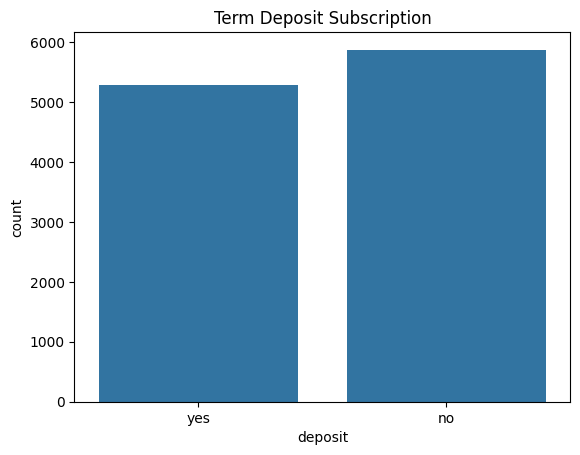

In [8]:
sns.countplot(x='deposit', data=df)
plt.title('Term Deposit Subscription')
plt.show()

Features and Target

In [9]:
X = df.drop('deposit', axis=1)
y = df['deposit']

Age Distribution

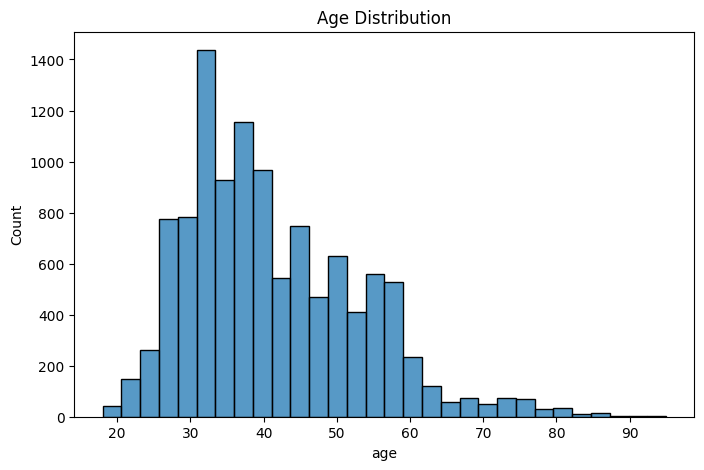

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=30
)

plt.title(
    'Age Distribution'
)

plt.show()

Correlation Heatmap

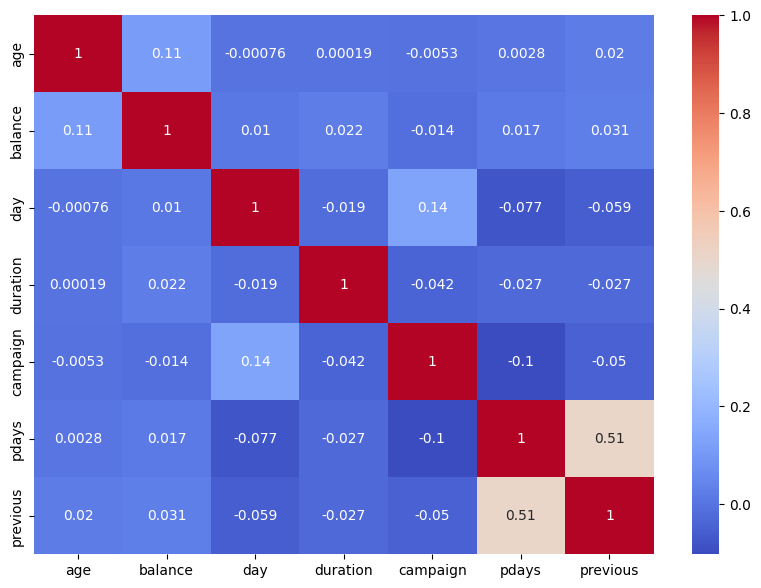

In [11]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

###Data Preprocessing

Encode Categorical Columns

In [12]:
le = LabelEncoder()

for col in df.select_dtypes(
        include='object'):
    df[col] = le.fit_transform(df[col])

In [13]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


Split the data

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

###Model 1: Logistic Regression

Train Model

In [24]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Predictions

In [25]:
lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(
    X_test
)[:,1]

Evaluation

In [26]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.80      0.82      0.81      1175
           1       0.79      0.77      0.78      1058

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233

F1 Score: 0.7786845895343255


Confusion Matrix

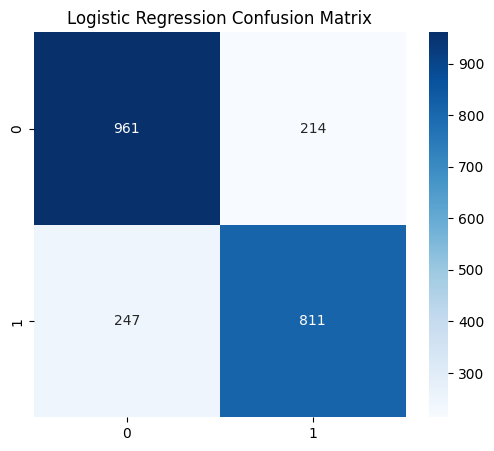

In [27]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Logistic Regression Confusion Matrix'
)

plt.show()

###Model 2: Random Forest

Train Model

In [28]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

Predictions

In [29]:
rf_pred = rf.predict(
    X_test
)

rf_prob = rf.predict_proba(
    X_test
)[:,1]

Evaluation

In [30]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1175
           1       0.83      0.88      0.85      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233

F1 Score: 0.8526989935956084


Confusion Matrix

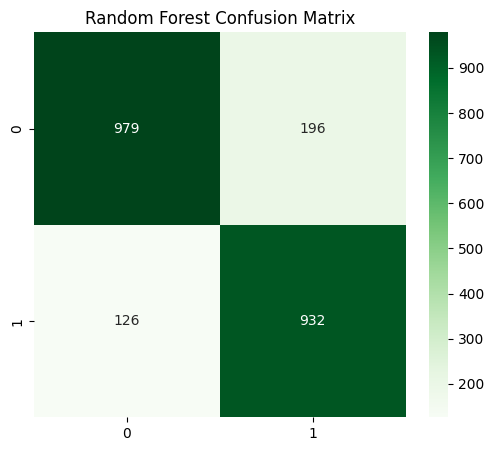

In [31]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Random Forest Confusion Matrix'
)

plt.show()

###ROC Curve

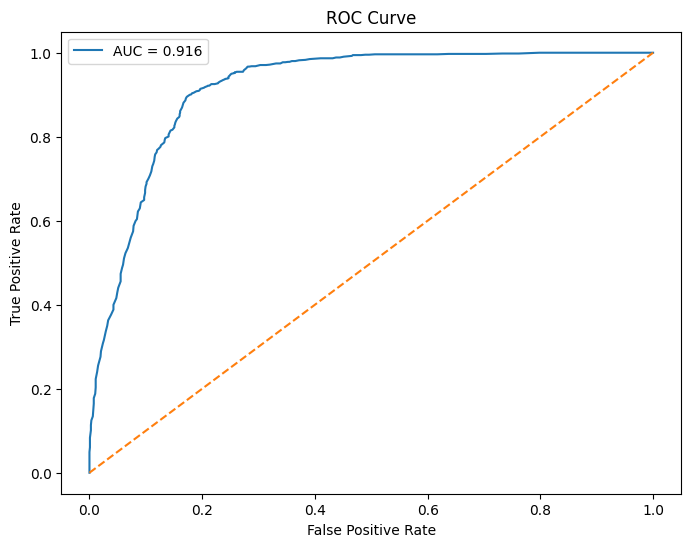

In [32]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_prob
)

auc = roc_auc_score(
    y_test,
    rf_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'ROC Curve'
)

plt.legend()

plt.show()

###Final Conclusion

The Bank Marketing dataset was analyzed to predict whether a customer would subscribe to a term deposit. Logistic Regression and Random Forest classification models were trained and evaluated using Confusion Matrix, F1 Score, and ROC Curve. Random Forest generally performed better than Logistic Regression. SHAP analysis was used to explain model predictions and identify the most influential factors affecting customer subscription decisions.